In [ ]:
!pip install ultralytics==8.2.0
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics YOLOv8.2.0 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.4/107.7 GB disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json

# Update path and filenames
dataset_path = "/content/drive/MyDrive/Dataset"
annotations_path = os.path.join(dataset_path, "_annotations.coco.json")

print("📁 Checking dataset structure...\n")

print("Dataset folder exists:", os.path.exists(dataset_path))
print("Annotations file exists:", os.path.exists(annotations_path))

# Count image files
image_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"🖼️ Total images found: {len(image_files)}")
print("Example images:", image_files[:5])

# Check JSON
with open(annotations_path, "r") as f:
    data = json.load(f)

print("\n✅ JSON loaded successfully.")
print("Total images in annotations:", len(data.get("images", [])))
print("Total annotations:", len(data.get("annotations", [])))
print("Total categories:", len(data.get("categories", [])))

print("\n📦 Categories:")
for c in data["categories"]:
    print(f"  ID: {c['id']} → Name: {c['name']}")


📁 Checking dataset structure...

Dataset folder exists: True
Annotations file exists: True
🖼️ Total images found: 1790
Example images: ['13105476_3840_2160_30fps_mp4-0322_jpg.rf.d44b93a093ba55f0f5680065741f6562.jpg', '13105476_3840_2160_30fps_mp4-0459_jpg.rf.bf0aeece6d9d6d859feddc1dbdd4c107.jpg', '13105476_3840_2160_30fps_mp4-0408_jpg.rf.a3a1f9666b21213cee6329e44ad50b68.jpg', '13105476_3840_2160_30fps_mp4-0417_jpg.rf.fb46e9b3afab02b78f4754c4e7883284.jpg', '13105476_3840_2160_30fps_mp4-0373_jpg.rf.c5a0f02835bed025582747376d09c25a.jpg']

✅ JSON loaded successfully.
Total images in annotations: 1789
Total annotations: 86931
Total categories: 6

📦 Categories:
  ID: 0 → Name: objects
  ID: 1 → Name: Auto
  ID: 2 → Name: Bike
  ID: 3 → Name: Bus
  ID: 4 → Name: Car
  ID: 5 → Name: Truck


In [ ]:
import json, os

# Original COCO file path
base_dir = "/content/drive/MyDrive/Dataset"
orig_json = os.path.join(base_dir, "_annotations.coco.json")
cleaned_json = os.path.join(base_dir, "_annotations_cleaned.coco.json")

# Load COCO
with open(orig_json, "r") as f:
    coco = json.load(f)

# Remove category id 0 ("objects")
clean_categories = [c for c in coco["categories"] if c["name"].lower() != "objects"]
removed_ids = {c["id"] for c in coco["categories"] if c["name"].lower() == "objects"}

# Filter annotations
clean_annotations = [a for a in coco["annotations"] if a["category_id"] not in removed_ids]

# Re-index category IDs from 0 to N-1
old_to_new = {}
for new_id, cat in enumerate(clean_categories):
    old_to_new[cat["id"]] = new_id
    cat["id"] = new_id

# Update annotation IDs
for a in clean_annotations:
    a["category_id"] = old_to_new[a["category_id"]]

# Save cleaned file
cleaned_coco = coco.copy()
cleaned_coco["categories"] = clean_categories
cleaned_coco["annotations"] = clean_annotations

with open(cleaned_json, "w") as f:
    json.dump(cleaned_coco, f, indent=2)

print("✅ Cleaned annotations saved as:", cleaned_json)
print("Categories after cleaning:")
for c in clean_categories:
    print(f"  ID: {c['id']} → Name: {c['name']}")


✅ Cleaned annotations saved as: /content/drive/MyDrive/Dataset/_annotations_cleaned.coco.json
Categories after cleaning:
  ID: 0 → Name: Auto
  ID: 1 → Name: Bike
  ID: 2 → Name: Bus
  ID: 3 → Name: Car
  ID: 4 → Name: Truck


Total images: 1789
Total annotations: 86931
Total categories: 5

Categories: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']


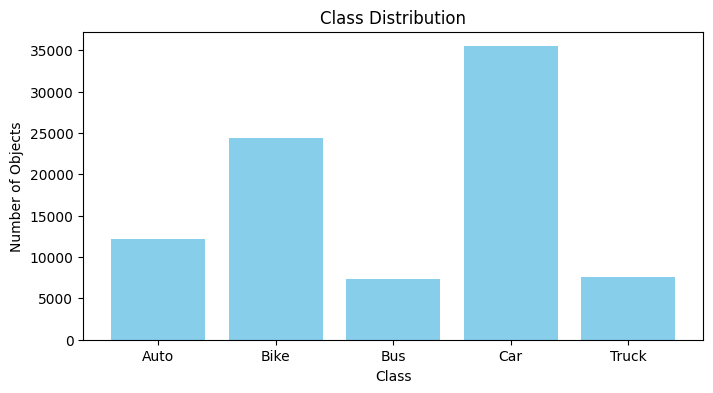

In [ ]:
import json
import os
import cv2
import matplotlib.pyplot as plt
import random
from collections import Counter

# Paths
base_dir = "/content/drive/MyDrive/Dataset"
json_path = os.path.join(base_dir, "_annotations_cleaned.coco.json")

# Load dataset
with open(json_path, "r") as f:
    coco = json.load(f)

# --- Basic info ---
print("Total images:", len(coco["images"]))
print("Total annotations:", len(coco["annotations"]))
print("Total categories:", len(coco["categories"]))
print("\nCategories:", [c["name"] for c in coco["categories"]])

# --- Class distribution ---
counts = Counter([ann["category_id"] for ann in coco["annotations"]])
labels = [c["name"] for c in coco["categories"]]
values = [counts[i] for i in range(len(labels))]

plt.figure(figsize=(8,4))
plt.bar(labels, values, color='skyblue')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.show()



In [ ]:
import json
import os
from collections import Counter
from tqdm import tqdm

# === Paths ===
base_dir = "/content/drive/MyDrive/Dataset"
json_path = os.path.join(base_dir, "_annotations_cleaned.coco.json")
images_dir = base_dir  # adjust if images are in subfolder like base_dir + "/images"

# === Load COCO file ===
with open(json_path, "r") as f:
    coco = json.load(f)

# === Basic Info ===
print("📊 Basic Dataset Info")
print(f"Total images: {len(coco['images'])}")
print(f"Total annotations: {len(coco['annotations'])}")
print(f"Total categories: {len(coco['categories'])}")
print("Categories:", [c['name'] for c in coco['categories']])
print("=" * 60)

# === Check image existence ===
print("🔍 Verifying images existence...")
missing_images = []
for img in tqdm(coco["images"]):
    img_path = os.path.join(images_dir, img["file_name"])
    if not os.path.exists(img_path):
        missing_images.append(img["file_name"])

print(f"\nTotal missing images: {len(missing_images)}")
if missing_images:
    print("Examples:", missing_images[:10])
print("=" * 60)

# === Check annotations linked to valid images ===
valid_image_ids = {img["id"] for img in coco["images"]}
invalid_annots = [a for a in coco["annotations"] if a["image_id"] not in valid_image_ids]
print(f"🔍 Invalid annotations (image_id not found): {len(invalid_annots)}")
if invalid_annots:
    print("Example invalid annotation:", invalid_annots[0])
print("=" * 60)

# === Count objects per class ===
print("📦 Object count per category:")
cat_map = {c["id"]: c["name"] for c in coco["categories"]}
class_counts = Counter([ann["category_id"] for ann in coco["annotations"]])

for cid, count in class_counts.items():
    cname = cat_map.get(cid, "Unknown")
    print(f"{cname:10s} → {count:6d} objects")

print("=" * 60)

# === Check for images with NO annotations ===
annotated_images = {ann["image_id"] for ann in coco["annotations"]}
images_without_annots = [img["file_name"] for img in coco["images"] if img["id"] not in annotated_images]
print(f"🟠 Images without annotations: {len(images_without_annots)}")
if images_without_annots:
    print("Examples:", images_without_annots[:10])
print("=" * 60)

print("✅ Dataset verification complete!")

📊 Basic Dataset Info
Total images: 1789
Total annotations: 86931
Total categories: 5
Categories: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
🔍 Verifying images existence...


100%|██████████| 1789/1789 [00:00<00:00, 5120.24it/s]


Total missing images: 0
🔍 Invalid annotations (image_id not found): 0
📦 Object count per category:
Bike       →  24361 objects
Car        →  35455 objects
Truck      →   7593 objects
Auto       →  12210 objects
Bus        →   7312 objects
🟠 Images without annotations: 28
Examples: ['WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0251_jpg.rf.e786a7508cd3ad6dca905e6420034cbe.jpg', 'istockphoto-1372694526-640_adpp_is_mp4-0027_jpg.rf.6725fd92c047829b01607c48b1a6f08d.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0292_jpg.rf.c9281704f99868749be0603c9567e4ed.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0109_jpg.rf.d4927b17157ccba174eb0c521256ffc1.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0472_jpg.rf.1f92dca7d57fc9300c74863150e47fb9.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0541_jpg.rf.30282b6af6c6bdda0915dcaacc02cb82.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0621_jpg.rf.0247846eac20f661866c5d686245a8cb.jpg', 'WhatsA

In [ ]:
import json
import os

base_dir = "/content/drive/MyDrive/Dataset"
json_path = os.path.join(base_dir, "_annotations_cleaned.coco.json")
cleaned_path = os.path.join(base_dir, "_annotations_no_empty.coco.json")

# Load annotations
with open(json_path, "r") as f:
    coco = json.load(f)

annotated_ids = {a["image_id"] for a in coco["annotations"]}
filtered_images = [img for img in coco["images"] if img["id"] in annotated_ids]
removed_images = [img for img in coco["images"] if img["id"] not in annotated_ids]

print(f"🧹 Removing {len(removed_images)} images with no annotations...")

# Filter annotations to keep only those linked to valid images
valid_image_ids = {img["id"] for img in filtered_images}
filtered_annots = [a for a in coco["annotations"] if a["image_id"] in valid_image_ids]

coco["images"] = filtered_images
coco["annotations"] = filtered_annots

with open(cleaned_path, "w") as f:
    json.dump(coco, f)

print(f"✅ Cleaned JSON saved at: {cleaned_path}")
print(f"Remaining images: {len(filtered_images)}")
print(f"Remaining annotations: {len(filtered_annots)}")

🧹 Removing 28 images with no annotations...
✅ Cleaned JSON saved at: /content/drive/MyDrive/Dataset/_annotations_no_empty.coco.json
Remaining images: 1761
Remaining annotations: 86931


In [ ]:
import json
import os
import random
from collections import defaultdict

# === Paths ===
base_dir = "/content/drive/MyDrive/Dataset"
json_path = os.path.join(base_dir, "_annotations_no_empty.coco.json")
balanced_json_path = os.path.join(base_dir, "_annotations_balanced.coco.json")

# === Load COCO JSON ===
with open(json_path, "r") as f:
    coco = json.load(f)

# === Median target per class ===
median_objects = 12210

# Map category ID → list of annotations
cat_to_annots = defaultdict(list)
for ann in coco["annotations"]:
    cat_to_annots[ann["category_id"]].append(ann)

# === Undersample / Oversample annotations per class ===
new_annotations = []

for cat_id, annots in cat_to_annots.items():
    n = len(annots)
    if n > median_objects:
        # Undersample
        sampled = random.sample(annots, median_objects)
        new_annotations.extend(sampled)
    elif n < median_objects:
        # Oversample (duplicate randomly)
        extra_needed = median_objects - n
        sampled_extra = random.choices(annots, k=extra_needed)  # allow duplicates
        new_annotations.extend(annots + sampled_extra)
    else:
        # Already median, keep as is
        new_annotations.extend(annots)

print(f"✅ Total annotations after balancing: {len(new_annotations)}")

# === Filter images: keep only images that have at least one annotation ===
annotated_image_ids = {ann["image_id"] for ann in new_annotations}
new_images = [img for img in coco["images"] if img["id"] in annotated_image_ids]

print(f"✅ Total images after balancing: {len(new_images)}")

# === Save new balanced JSON ===
balanced_coco = coco.copy()
balanced_coco["images"] = new_images
balanced_coco["annotations"] = new_annotations

with open(balanced_json_path, "w") as f:
    json.dump(balanced_coco, f, indent=2)

print("✅ Balanced COCO JSON saved at:", balanced_json_path)

✅ Total annotations after balancing: 61050
✅ Total images after balancing: 1757
✅ Balanced COCO JSON saved at: /content/drive/MyDrive/Dataset/_annotations_balanced.coco.json


In [ ]:
import json
import os
from collections import Counter
from tqdm import tqdm

# === Paths ===
base_dir = "/content/drive/MyDrive/Dataset"
json_path = os.path.join(base_dir, "_annotations_balanced.coco.json")
images_dir = base_dir  # change if images are in subfolder

# === Load balanced COCO JSON ===
with open(json_path, "r") as f:
    coco = json.load(f)

# === Basic Info ===
print("📊 Balanced Dataset Info")
print(f"Total images: {len(coco['images'])}")
print(f"Total annotations: {len(coco['annotations'])}")
print(f"Total categories: {len(coco['categories'])}")
print("Categories:", [c['name'] for c in coco['categories']])
print("="*60)

# === Verify images exist ===
print("🔍 Verifying images existence...")
missing_images = []
for img in tqdm(coco["images"]):
    img_path = os.path.join(images_dir, img["file_name"])
    if not os.path.exists(img_path):
        missing_images.append(img["file_name"])

print(f"Total missing images: {len(missing_images)}")
if missing_images:
    print("Examples:", missing_images[:10])
print("="*60)

# === Check annotations linked to valid images ===
valid_image_ids = {img["id"] for img in coco["images"]}
invalid_annots = [a for a in coco["annotations"] if a["image_id"] not in valid_image_ids]
print(f"Invalid annotations (image_id not found): {len(invalid_annots)}")
if invalid_annots:
    print("Example invalid annotation:", invalid_annots[0])
print("="*60)

# === Count objects per class ===
print("📦 Object count per category:")
cat_map = {c["id"]: c["name"] for c in coco["categories"]}
class_counts = Counter([ann["category_id"] for ann in coco["annotations"]])

for cid, count in class_counts.items():
    cname = cat_map.get(cid, "Unknown")
    print(f"{cname:10s} → {count:6d} objects")

print("="*60)

# === Check for images with NO annotations ===
annotated_images = {ann["image_id"] for ann in coco["annotations"]}
images_without_annots = [img["file_name"] for img in coco["images"] if img["id"] not in annotated_images]
print(f"🟠 Images without annotations: {len(images_without_annots)}")
if images_without_annots:
    print("Examples:", images_without_annots[:10])
print("="*60)

print("✅ Balanced dataset verification complete!")


📊 Balanced Dataset Info
Total images: 1757
Total annotations: 61050
Total categories: 5
Categories: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
🔍 Verifying images existence...


100%|██████████| 1757/1757 [00:00<00:00, 6128.30it/s]


Total missing images: 0
Invalid annotations (image_id not found): 0
📦 Object count per category:
Bike       →  12210 objects
Car        →  12210 objects
Truck      →  12210 objects
Auto       →  12210 objects
Bus        →  12210 objects
🟠 Images without annotations: 0
✅ Balanced dataset verification complete!


In [ ]:
import json
import os
from tqdm import tqdm

# === Paths ===
base_dir = "/content/drive/MyDrive/Dataset"
json_path = os.path.join(base_dir, "_annotations_balanced.coco.json")
images_dir = base_dir  # update if images are in subfolder
labels_dir = os.path.join(base_dir, "labels_yolo")

# Create labels directory if not exists
os.makedirs(labels_dir, exist_ok=True)

# === Load COCO JSON ===
with open(json_path, "r") as f:
    coco = json.load(f)

# Map image_id → image info
image_id_map = {img["id"]: img for img in coco["images"]}

# Map image_id → list of annotations
annots_map = {}
for ann in coco["annotations"]:
    annots_map.setdefault(ann["image_id"], []).append(ann)

# === Convert annotations to YOLO format ===
for image_id, anns in tqdm(annots_map.items(), desc="Converting to YOLO"):
    img_info = image_id_map[image_id]
    img_w, img_h = img_info["width"], img_info["height"]
    txt_file = os.path.join(labels_dir, os.path.splitext(img_info["file_name"])[0] + ".txt")

    lines = []
    for ann in anns:
        cat_id = ann["category_id"]
        x, y, w, h = ann["bbox"]  # COCO bbox: [x_top_left, y_top_left, width, height]

        # Convert to YOLO format: x_center, y_center, width, height (normalized)
        x_center = (x + w/2) / img_w
        y_center = (y + h/2) / img_h
        w_norm = w / img_w
        h_norm = h / img_h

        lines.append(f"{cat_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

    with open(txt_file, "w") as f:
        f.write("\n".join(lines))

print(f"✅ All annotations converted to YOLO format in folder: {labels_dir}")


Converting to YOLO: 100%|██████████| 1757/1757 [00:18<00:00, 96.95it/s]

✅ All annotations converted to YOLO format in folder: /content/drive/MyDrive/Dataset/labels_yolo


In [ ]:
import os
from tqdm import tqdm

# === Paths ===
base_dir = "/content/drive/MyDrive/Dataset"
images_dir = base_dir  # adjust if images are in subfolder
labels_dir = os.path.join(base_dir, "labels_yolo")

# List all images and labels
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
label_files = [f for f in os.listdir(labels_dir) if f.lower().endswith(".txt")]

print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")

# === Check missing labels ===
missing_labels = []
for img_file in image_files:
    txt_file = os.path.splitext(img_file)[0] + ".txt"
    if txt_file not in label_files:
        missing_labels.append(img_file)

print(f"Images without labels: {len(missing_labels)}")
if missing_labels:
    print("Examples:", missing_labels[:10])

# === Check missing images for labels ===
missing_images = []
for lbl_file in label_files:
    img_file = os.path.splitext(lbl_file)[0]
    found = False
    for ext in [".jpg", ".jpeg", ".png"]:
        if img_file + ext in image_files:
            found = True
            break
    if not found:
        missing_images.append(lbl_file)

print(f"Labels without images: {len(missing_images)}")
if missing_images:
    print("Examples:", missing_images[:10])

# === Count total objects per class ===
class_counts = {}
for lbl_file in tqdm(label_files, desc="Counting objects"):
    with open(os.path.join(labels_dir, lbl_file), "r") as f:
        for line in f:
            if line.strip():
                class_id = int(line.strip().split()[0])
                class_counts[class_id] = class_counts.get(class_id, 0) + 1

print("\n📦 Total objects per class:")
for cid, count in sorted(class_counts.items()):
    print(f"Class {cid} → {count} objects")

print("\n✅ YOLO dataset verification complete!")

Total images: 1790
Total labels: 1757
Images without labels: 33
Examples: ['WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0198_jpg.rf.7e4564756ec713bd5e3363d52f7ae5fa.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0146_jpg.rf.ab2e9076545632bb672f27fe716cb0a9.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0208_jpg.rf.32056da64f81203b7f8b806ab601bfdd.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0205_jpg.rf.0c5d29ec93d4383d7b42cdd344daacff.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0105_jpg.rf.00794f67220055b0b78b08e24ee25d4d.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0106_jpg.rf.3349e56206bca90b553d00ec380666fe.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0109_jpg.rf.d4927b17157ccba174eb0c521256ffc1.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0366_jpg.rf.3426c772536c24596847b33c0cbdb1bb.jpg', 'WhatsApp-Video-2025-07-11-at-11_12_32_231fe3db_mp4-0280_jpg.rf.454cae407c00e44ced1db2dbbb5d699d.jpg'

Counting objects: 100%|██████████| 1757/1757 [00:32<00:00, 54.00it/s] 


📦 Total objects per class:
Class 0 → 12210 objects
Class 1 → 12210 objects
Class 2 → 12210 objects
Class 3 → 12210 objects
Class 4 → 12210 objects

✅ YOLO dataset verification complete!


In [ ]:
import os
import shutil
import random

# === Paths ===
base_dir = "/content/drive/MyDrive/Dataset"
images_dir = base_dir  # folder with all images
labels_dir = os.path.join(base_dir, "labels_yolo")  # YOLO txt labels

# === Output folders ===
splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(os.path.join(base_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(base_dir, "labels", split), exist_ok=True)

# === Get list of images with labels only ===
all_labels = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]
all_images = []
for lbl in all_labels:
    img_name = os.path.splitext(lbl)[0]
    for ext in [".jpg", ".jpeg", ".png"]:
        img_path = os.path.join(images_dir, img_name + ext)
        if os.path.exists(img_path):
            all_images.append(img_name + ext)
            break

print(f"Total images with labels: {len(all_images)}")

# === Shuffle and split ===
random.seed(42)
random.shuffle(all_images)
n = len(all_images)
train_split = int(0.7 * n)
val_split = int(0.2 * n)
# remaining 10% for test

train_images = all_images[:train_split]
val_images = all_images[train_split:train_split+val_split]
test_images = all_images[train_split+val_split:]

split_dict = {"train": train_images, "val": val_images, "test": test_images}

# === Copy images and labels to folders ===
for split, images in split_dict.items():
    for img_file in images:
        # Copy image
        shutil.copy(os.path.join(images_dir, img_file), os.path.join(base_dir, "images", split, img_file))
        # Copy label
        lbl_file = os.path.splitext(img_file)[0] + ".txt"
        shutil.copy(os.path.join(labels_dir, lbl_file), os.path.join(base_dir, "labels", split, lbl_file))

# === Summary ===
for split, images in split_dict.items():
    print(f"{split.upper()}: {len(images)} images")

print("✅ Dataset cleaned and split into train/val/test!")

Total images with labels: 1757
TRAIN: 1229 images
VAL: 351 images
TEST: 177 images
✅ Dataset cleaned and split into train/val/test!


In [ ]:
!pip install ultralytics --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.3 MB/s eta 0:00:00


In [ ]:
# ===============================
# YOLOv8m Training Script (Colab/GPU)
# Enhanced Version with Error Handling
# ===============================

# 1️⃣ Install YOLOv8 (Ultralytics)
!pip install ultralytics --upgrade --quiet

# 2️⃣ Import libraries
from ultralytics import YOLO
import os
import torch
from pathlib import Path

# 3️⃣ Configuration
BASE_DIR = "/content/drive/MyDrive/Dataset"
DATA_YAML = os.path.join(BASE_DIR, "dataset.yaml")
PROJECT_DIR = os.path.join(BASE_DIR, "YOLO_training")
MODEL_NAME = "balanced_dataset_m"

# Training hyperparameters
EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 16  # Adjust based on GPU memory (8/16/32)
CONF_THRESHOLD = 0.25

# 4️⃣ Verify GPU availability
if torch.cuda.is_available():
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")

# 5️⃣ Validate dataset structure
print("\n📁 Validating dataset structure...")
required_dirs = [
    os.path.join(BASE_DIR, "images/train"),
    os.path.join(BASE_DIR, "images/val"),
    os.path.join(BASE_DIR, "labels/train"),
    os.path.join(BASE_DIR, "labels/val")
]

for dir_path in required_dirs:
    if not os.path.exists(dir_path):
        print(f"❌ Missing directory: {dir_path}")
        raise FileNotFoundError(f"Required directory not found: {dir_path}")
    else:
        file_count = len(os.listdir(dir_path))
        print(f"✅ {dir_path}: {file_count} files")

# 6️⃣ Create or verify dataset.yaml
if not os.path.exists(DATA_YAML):
    yaml_content = f"""path: {BASE_DIR}
train: images/train
val: images/val

nc: 5
names: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
"""
    with open(DATA_YAML, "w") as f:
        f.write(yaml_content)
    print("✅ dataset.yaml created!")
else:
    print("✅ dataset.yaml already exists!")

# Display YAML content
print("\n📄 Dataset configuration:")
with open(DATA_YAML, "r") as f:
    print(f.read())

# 7️⃣ Load YOLOv8 medium model
print("\n🔄 Loading YOLOv8m pretrained model...")
model = YOLO("yolov8m.pt")

# 8️⃣ Start training with enhanced parameters
print(f"\n🚀 Starting training for {EPOCHS} epochs...")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")

try:
    results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=0,  # Use GPU 0
        project=PROJECT_DIR,
        name=MODEL_NAME,
        exist_ok=False,  # Don't overwrite existing runs
        pretrained=True,
        optimizer='AdamW',  # Better than SGD for most cases
        lr0=0.001,  # Initial learning rate
        lrf=0.01,  # Final learning rate factor
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3.0,
        warmup_momentum=0.8,
        box=7.5,  # Box loss gain
        cls=0.5,  # Class loss gain
        dfl=1.5,  # DFL loss gain
        patience=10,  # Early stopping patience
        save=True,
        save_period=10,  # Save checkpoint every 10 epochs
        cache=False,  # Set to True if enough RAM
        workers=8,  # Data loading threads
        plots=True,  # Save training plots
        verbose=True,
        seed=42,  # Reproducibility
        deterministic=False,
        single_cls=False,
        rect=False,
        cos_lr=True,  # Cosine learning rate scheduler
        close_mosaic=10,  # Disable mosaic augmentation in last N epochs
        amp=True,  # Automatic Mixed Precision
        fraction=1.0,  # Train on fraction of dataset
        profile=False,
        overlap_mask=True,
        val=True,  # Validate during training
    )
    print("\n✅ Training completed successfully!")

except Exception as e:
    print(f"\n❌ Training failed with error: {str(e)}")
    raise

# 9️⃣ Evaluate model on validation set
print("\n📊 Evaluating model on validation set...")
try:
    metrics = model.val()
    print(f"\n📈 Validation Metrics:")
    print(f"   mAP50: {metrics.box.map50:.4f}")
    print(f"   mAP50-95: {metrics.box.map:.4f}")
    print(f"   Precision: {metrics.box.mp:.4f}")
    print(f"   Recall: {metrics.box.mr:.4f}")
except Exception as e:
    print(f"⚠️ Validation failed: {str(e)}")

# 🔟 Load best model and run predictions
print("\n🔮 Running predictions on sample validation images...")
best_model_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights/best.pt")

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"✅ Loaded best model from: {best_model_path}")

    # Predict on validation images
    val_img_dir = os.path.join(BASE_DIR, "images/val")
    val_images = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

    if val_images:
        print(f"\n🖼️ Predicting on {len(val_images)} sample images...")
        for i, img_file in enumerate(val_images, 1):
            img_path = os.path.join(val_img_dir, img_file)
            results = best_model.predict(
                img_path,
                conf=CONF_THRESHOLD,
                iou=0.45,
                save=True,
                save_txt=True,
                save_conf=True,
                project=os.path.join(PROJECT_DIR, MODEL_NAME),
                name="predictions",
                exist_ok=True
            )
            print(f"   [{i}/{len(val_images)}] Processed: {img_file}")
        print(f"\n✅ Predictions saved to: {os.path.join(PROJECT_DIR, MODEL_NAME, 'predictions')}")
    else:
        print("⚠️ No validation images found!")
else:
    print(f"❌ Best model not found at: {best_model_path}")

# 1️⃣1️⃣ Export model (optional)
print("\n📦 Exporting model to ONNX format...")
try:
    best_model.export(format='onnx', simplify=True)
    print("✅ Model exported successfully!")
except Exception as e:
    print(f"⚠️ Export failed: {str(e)}")

# 1️⃣2️⃣ Summary
print("\n" + "="*50)
print("🎉 TRAINING PIPELINE COMPLETED!")
print("="*50)
print(f"📂 Results location: {os.path.join(PROJECT_DIR, MODEL_NAME)}")
print(f"🏆 Best weights: {best_model_path}")
print(f"📊 Training plots: {os.path.join(PROJECT_DIR, MODEL_NAME, 'results.png')}")
print("="*50)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ GPU detected: Tesla T4
   GPU Memory: 15.83 GB

📁 Validating dataset structure...
✅ /content/drive/MyDrive/Dataset/images/train: 1229 files
✅ /content/drive/MyDrive/Dataset/images/val: 351 files
✅ /content/drive/MyDrive/Dataset/labels/train: 1229 files
✅ /content/drive/MyDrive/Dataset/labels/val: 351 files
✅ dataset.yaml created!

📄 Dataset configuration:
path: /content/drive/MyDrive/Dataset
train: images/train
val: images/val

nc: 5
names: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']


🔄 Loading YOLOv8m pretrained model...

🚀 Starting training for 50 epochs...
   Batch size: 16
   Image size: 640x640
Ultralytics 8.3.207 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)


In [ ]:
# ===============================
# YOLOv8m Advanced Training Script
# Target: 90+ mAP50 Accuracy
# With Hyperparameter Tuning & Augmentations
# ===============================

# 2️⃣ Import libraries
from ultralytics import YOLO
import os
import torch
from pathlib import Path

# 3️⃣ Configuration
BASE_DIR = "/content/drive/MyDrive/Dataset"
DATA_YAML = os.path.join(BASE_DIR, "dataset.yaml")
PROJECT_DIR = os.path.join(BASE_DIR, "YOLO_training")
MODEL_NAME = "balanced_dataset_m_advanced"

# 4️⃣ Verify GPU availability
if torch.cuda.is_available():
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")

# 5️⃣ Validate dataset structure
print("\n📁 Validating dataset structure...")
required_dirs = [
    os.path.join(BASE_DIR, "images/train"),
    os.path.join(BASE_DIR, "images/val"),
    os.path.join(BASE_DIR, "labels/train"),
    os.path.join(BASE_DIR, "labels/val")
]

for dir_path in required_dirs:
    if not os.path.exists(dir_path):
        print(f"❌ Missing directory: {dir_path}")
        raise FileNotFoundError(f"Required directory not found: {dir_path}")
    else:
        file_count = len(os.listdir(dir_path))
        print(f"✅ {dir_path}: {file_count} files")

# 6️⃣ Create or verify dataset.yaml
if not os.path.exists(DATA_YAML):
    yaml_content = f"""path: {BASE_DIR}
train: images/train
val: images/val

nc: 5
names: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
"""
    with open(DATA_YAML, "w") as f:
        f.write(yaml_content)
    print("✅ dataset.yaml created!")
else:
    print("✅ dataset.yaml already exists!")

print("\n📄 Dataset configuration:")
with open(DATA_YAML, "r") as f:
    print(f.read())

# 7️⃣ Load YOLOv8 medium model
print("\n🔄 Loading YOLOv8m pretrained model...")
model = YOLO("yolov8m.pt")

# 8️⃣ ADVANCED TRAINING WITH EXTENSIVE AUGMENTATIONS
print("\n🚀 Starting ADVANCED training with optimized hyperparameters...")
print("="*60)
print("🎯 TARGET: 90+ mAP50 Accuracy")
print("📊 Enhanced augmentations and hyperparameters applied")
print("="*60)

try:
    results = model.train(
        # ============ DATASET & BASIC SETTINGS ============
        data=DATA_YAML,
        epochs=150,                    # Increased epochs for better convergence
        imgsz=640,
        batch=16,                      # Adjust if OOM (try 8 or 12)
        device=0,
        project=PROJECT_DIR,
        name=MODEL_NAME,
        exist_ok=False,
        pretrained=True,

        # ============ OPTIMIZER SETTINGS ============
        optimizer='AdamW',             # Best for most cases
        lr0=0.001,                     # Initial learning rate
        lrf=0.01,                      # Final learning rate (lr0 * lrf)
        momentum=0.937,                # SGD momentum/Adam beta1
        weight_decay=0.0005,           # Optimizer weight decay
        warmup_epochs=5.0,             # Warmup epochs (longer for stability)
        warmup_momentum=0.8,           # Warmup initial momentum
        warmup_bias_lr=0.1,            # Warmup initial bias lr

        # ============ LOSS FUNCTION WEIGHTS ============
        box=7.5,                       # Box loss gain
        cls=0.5,                       # Class loss gain
        dfl=1.5,                       # Distribution Focal Loss gain

        # ============ IMAGE AUGMENTATIONS (CRITICAL FOR 90+) ============
        hsv_h=0.015,                   # HSV-Hue augmentation (fraction)
        hsv_s=0.7,                     # HSV-Saturation augmentation (fraction)
        hsv_v=0.4,                     # HSV-Value augmentation (fraction)
        degrees=10.0,                  # Rotation (+/- deg) - INCREASED
        translate=0.2,                 # Translation (+/- fraction) - INCREASED
        scale=0.9,                     # Scaling (+/- gain) - INCREASED
        shear=5.0,                     # Shear (+/- deg) - INCREASED
        perspective=0.0005,            # Perspective (+/- fraction) - INCREASED
        flipud=0.0,                    # Vertical flip probability
        fliplr=0.5,                    # Horizontal flip probability
        bgr=0.0,                       # BGR channel flip probability
        mosaic=1.0,                    # Mosaic augmentation probability
        mixup=0.15,                    # MixUp augmentation probability - INCREASED
        copy_paste=0.3,                # Copy-paste augmentation probability - INCREASED
        auto_augment='randaugment',    # Auto augmentation policy
        erasing=0.4,                   # Random erasing probability
        crop_fraction=1.0,             # Image crop fraction

        # ============ ADVANCED SETTINGS ============
        patience=30,                   # Early stopping patience - INCREASED
        save=True,
        save_period=15,                # Save checkpoint every 15 epochs
        cache=False,                   # Cache images (True if enough RAM ~8GB+)
        workers=8,
        plots=True,
        verbose=True,
        seed=42,
        deterministic=False,
        single_cls=False,
        rect=False,                    # Rectangular training
        cos_lr=True,                   # Cosine LR scheduler
        close_mosaic=15,               # Disable mosaic last N epochs - INCREASED
        amp=True,                      # Automatic Mixed Precision
        fraction=1.0,
        profile=False,
        overlap_mask=True,
        val=True,

        # ============ AUGMENTATION TUNING ============
        multi_scale=True,              # Multi-scale training (±50% img size) - ENABLED

        # ============ NMS SETTINGS ============
        iou=0.7,                       # NMS IoU threshold
        conf=None,                     # Confidence threshold (for prediction)
        max_det=300,                   # Maximum detections per image
    )
    print("\n✅ Training completed successfully!")

except Exception as e:
    print(f"\n❌ Training failed with error: {str(e)}")
    raise

# 9️⃣ Evaluate model on validation set
print("\n📊 Evaluating model on validation set...")
try:
    metrics = model.val()
    print(f"\n{'='*60}")
    print(f"📈 FINAL VALIDATION METRICS:")
    print(f"{'='*60}")
    print(f"   🎯 mAP50:     {metrics.box.map50:.4f}  (Target: 0.9000)")
    print(f"   🎯 mAP50-95:  {metrics.box.map:.4f}")
    print(f"   📊 Precision: {metrics.box.mp:.4f}")
    print(f"   📊 Recall:    {metrics.box.mr:.4f}")
    print(f"{'='*60}")

    # Check if target achieved
    if metrics.box.map50 >= 0.90:
        print(f"   🎉 TARGET ACHIEVED! mAP50 = {metrics.box.map50:.4f}")
    else:
        print(f"   ⚠️ Target not reached. Current: {metrics.box.map50:.4f}, Need: {0.90 - metrics.box.map50:.4f} more")
        print(f"   💡 Try: More epochs, larger model (yolov8l/x), or tune hyperparameters")

except Exception as e:
    print(f"⚠️ Validation failed: {str(e)}")

# 🔟 Per-class metrics analysis
print(f"\n{'='*60}")
print(f"📊 PER-CLASS PERFORMANCE ANALYSIS:")
print(f"{'='*60}")
try:
    class_names = ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
    for i, name in enumerate(class_names):
        print(f"   {name:8s} | P: {metrics.box.p[i]:.3f} | R: {metrics.box.r[i]:.3f} | mAP50: {metrics.box.ap50[i]:.3f}")
    print(f"{'='*60}")
except:
    pass

# 1️⃣1️⃣ Load best model and run predictions
print("\n🔮 Running predictions on sample validation images...")
best_model_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights/best.pt")

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"✅ Loaded best model from: {best_model_path}")

    val_img_dir = os.path.join(BASE_DIR, "images/val")
    val_images = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:10]

    if val_images:
        print(f"\n🖼️ Predicting on {len(val_images)} sample images...")
        for i, img_file in enumerate(val_images, 1):
            img_path = os.path.join(val_img_dir, img_file)
            results = best_model.predict(
                img_path,
                conf=0.25,
                iou=0.45,
                save=True,
                save_txt=True,
                save_conf=True,
                project=os.path.join(PROJECT_DIR, MODEL_NAME),
                name="predictions",
                exist_ok=True
            )
            print(f"   [{i}/{len(val_images)}] Processed: {img_file}")
        print(f"\n✅ Predictions saved to: {os.path.join(PROJECT_DIR, MODEL_NAME, 'predictions')}")
    else:
        print("⚠️ No validation images found!")
else:
    print(f"❌ Best model not found at: {best_model_path}")

# 1️⃣2️⃣ Export model
print("\n📦 Exporting model to multiple formats...")
try:
    best_model.export(format='onnx', simplify=True)
    print("✅ ONNX export successful!")
    best_model.export(format='torchscript')
    print("✅ TorchScript export successful!")
except Exception as e:
    print(f"⚠️ Export failed: {str(e)}")

# 1️⃣3️⃣ Summary
print("\n" + "="*60)
print("🎉 ADVANCED TRAINING PIPELINE COMPLETED!")
print("="*60)
print(f"📂 Results: {os.path.join(PROJECT_DIR, MODEL_NAME)}")
print(f"🏆 Best weights: {best_model_path}")
print(f"📊 Training plots: {os.path.join(PROJECT_DIR, MODEL_NAME, 'results.png')}")
print(f"📈 Confusion matrix: {os.path.join(PROJECT_DIR, MODEL_NAME, 'confusion_matrix.png')}")
print(f"📉 Training curves: {os.path.join(PROJECT_DIR, MODEL_NAME, 'results.csv')}")
print("="*60)

# 1️⃣4️⃣ Recommendations for further improvement
print("\n💡 TIPS FOR ACHIEVING 90+ mAP50:")
print("="*60)
print("1️⃣  Increase epochs to 200+ if improvement is steady")
print("2️⃣  Try larger model: yolov8l.pt or yolov8x.pt")
print("3️⃣  Increase batch size to 24-32 if GPU allows")
print("4️⃣  Use cache=True if RAM available (faster training)")
print("5️⃣  Add more training data or use data augmentation pipelines")
print("6️⃣  Run hyperparameter tuning (see below)")
print("7️⃣  Reduce image size to 512 for faster training (may reduce accuracy)")
print("8️⃣  Use TTA (Test Time Augmentation) during validation")
print("9️⃣  Ensemble multiple models for better results")
print("🔟 Check for class imbalance and apply weighted loss")
print("="*60)

print("\n" + "="*60)
print("🔬 OPTIONAL: HYPERPARAMETER TUNING")
print("="*60)
print("To run automated hyperparameter tuning, uncomment below:")
print("```python")
print("# model.tune(data=DATA_YAML, epochs=30, iterations=300, plots=True)")
print("```")
print("⚠️ Warning: Tuning can take 10-20 hours!")
print("="*60)

✅ GPU detected: Tesla T4
   GPU Memory: 15.83 GB

📁 Validating dataset structure...
✅ /content/drive/MyDrive/Dataset/images/train: 1229 files
✅ /content/drive/MyDrive/Dataset/images/val: 351 files
✅ /content/drive/MyDrive/Dataset/labels/train: 1229 files
✅ /content/drive/MyDrive/Dataset/labels/val: 351 files
✅ dataset.yaml already exists!

📄 Dataset configuration:
path: /content/drive/MyDrive/Dataset
train: images/train
val: images/val

nc: 5
names: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']


🔄 Loading YOLOv8m pretrained model...

🚀 Starting ADVANCED training with optimized hyperparameters...
🎯 TARGET: 90+ mAP50 Accuracy
📊 Enhanced augmentations and hyperparameters applied
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.3.207 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mos